# 1. Import & Load Files

In [121]:
# essential import statments
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns

import folium
from folium.plugins import HeatMap
import networkx as nx
import geopandas as gpd

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [98]:
# Load borough & community level file (NYC) & get basic info
boros_nyc = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/final_project/data_boro/boros.geojson')

print(boros_nyc.head(3))
print("Borough CRS", boros_nyc.crs)

   OBJECTID  BoroCode  BoroName CountyFIPS NTACode        NTAName  \
0         1         3  Brooklyn        047    BK88   Borough Park   
1         2         4    Queens        081    QN51    Murray Hill   
2         3         4    Queens        081    QN27  East Elmhurst   

    Shape__Area  Shape__Length  \
0  5.400502e+07   39247.228028   
1  5.248828e+07   33266.904861   
2  1.972695e+07   19816.685003   

                                            geometry  
0  POLYGON ((-73.97605 40.63128, -73.97717 40.630...  
1  POLYGON ((-73.80379 40.77562, -73.80099 40.775...  
2  POLYGON ((-73.8611 40.76367, -73.85993 40.7622...  
Borough CRS EPSG:4326


In [10]:
# Filter the GeoDataFrame to keep only rows where the BoroName is "Brooklyn"
Brooklyn = boros_nyc[boros_nyc["BoroName"] == 'Brooklyn']

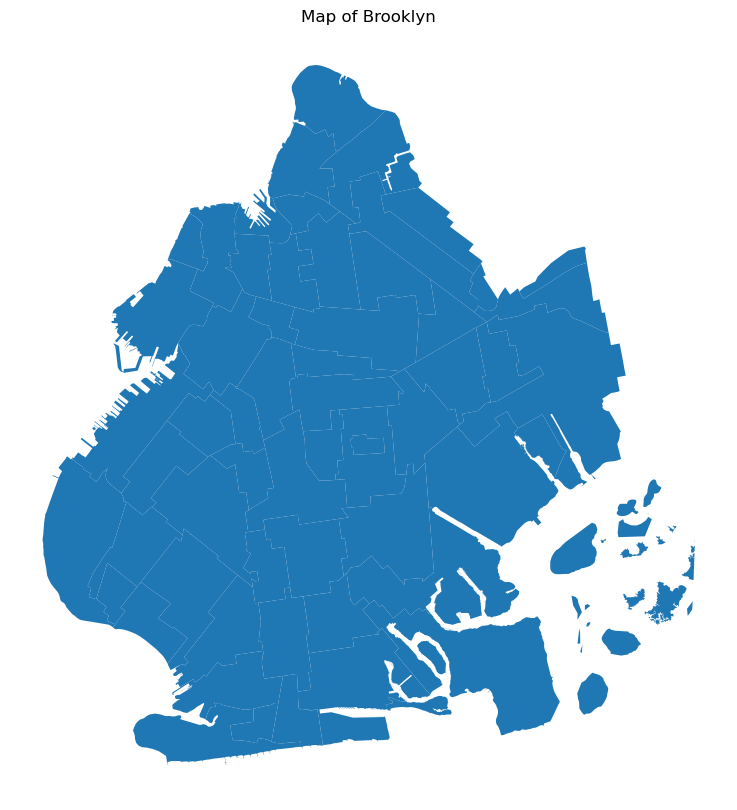

In [12]:
# show map of Brooklyn & remove axis 
fig, ax = plt.subplots(figsize=(10, 10))

Brooklyn.plot(ax=ax)

plt.title("Map of Brooklyn")
ax.axis('off')
plt.show()

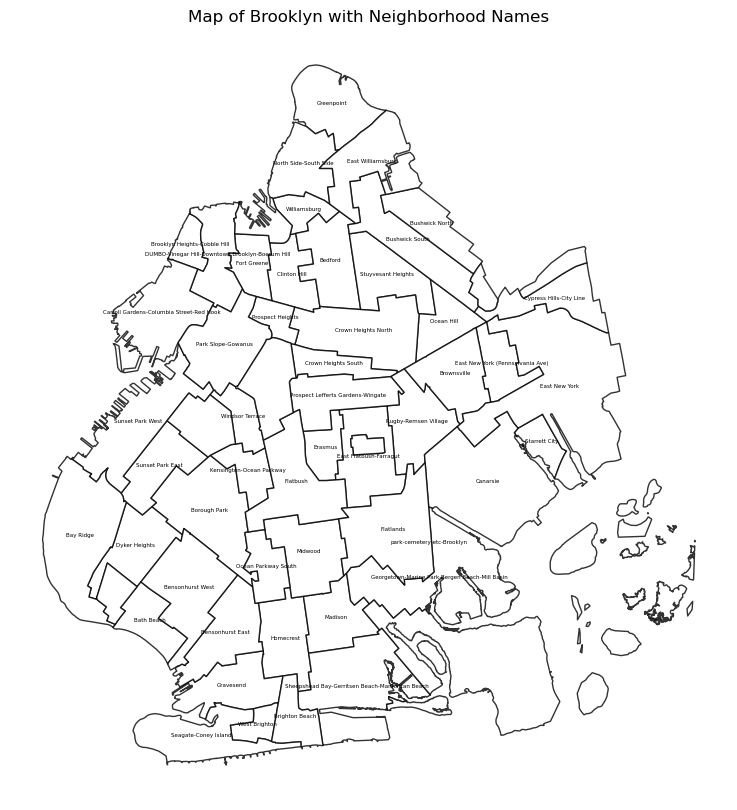

In [18]:
# Add labels for each neighborhood
fig, ax = plt.subplots(figsize=(10, 10))

Brooklyn.plot(ax=ax, color='white', edgecolor='black', alpha=0.8)

for idx, row in Brooklyn.iterrows():
    # Get the centroid of each neighborhood
    centroid = row['geometry'].centroid
    # Add the neighborhood name as a label
    ax.text(centroid.x, centroid.y, row['NTAName'], fontsize=4, ha='center', color='black')

# Title and show the map
ax.set_title("Map of Brooklyn with Neighborhood Names", fontsize=12)
ax.axis('off')
# plt.savefig("Map of Brooklyn with Neighborhood Names.png", dpi=300, transparent=True)
plt.show()

In [20]:
# load borough info on community level
nyct = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/final_project/data_boro/nyct2020_24d/nyct2020.shp')
nyct.head(3)

,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,GEOID,PUMA,Shape_Leng,Shape_Area,geometry
0,1,1,Manhattan,000100,1000100,None,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),36061000100,4121,10833.043929,1.843005e+06,"MULTIPOLYGON (((972081.788 190733.467, 972184...."
1,14.01,1,Manhattan,001401,1001401,None,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061001401,4103,5075.332000,1.006117e+06,"POLYGON ((987475.016 200297.218, 987705.443 20..."
2,14.02,1,Manhattan,001402,1001402,None,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061001402,4103,4459.156019,1.226206e+06,"POLYGON ((988387.669 201258.312, 988621.002 20..."


In [23]:
# Check CRS of the base map
print(nyct.crs)  
print(Brooklyn.crs) 

EPSG:2263
EPSG:4326


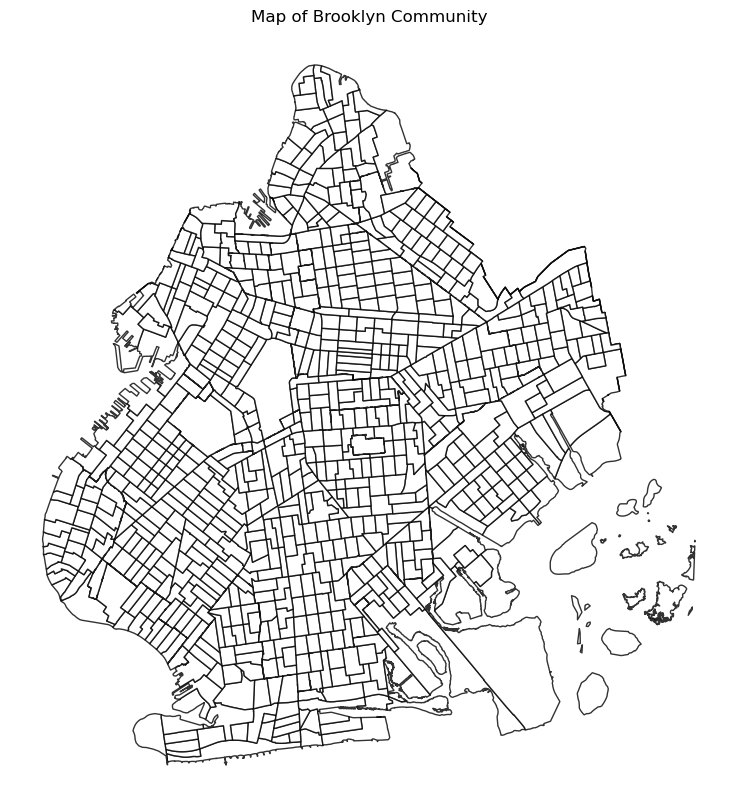

In [24]:
# Plot the community level map in Brooklyn
nyct_bk = nyct.to_crs(Brooklyn.crs)

community_bk = gpd.clip(nyct_bk, Brooklyn)

fig, ax = plt.subplots(figsize=(10, 10))

community_bk.plot(ax=ax, color='white', edgecolor='black', alpha=0.8)
plt.title("Map of Brooklyn Community")
ax.axis('off')
plt.show()

# 2. Analysis_Bus in Brooklyn

In [28]:
# load Bus stop shelter data 
bus_shelter_nyc = pd.read_csv(r'C:/Users/ALIENWARE/Desktop/final_project/data_bus/Bus_Stop_Shelter_20241122.csv')
bus_shelter_nyc.head(2)

,the_geom,BoroCode,BoroName,BoroCD,CounDist,AssemDist,StSenDist,CongDist,Shelter_ID,Corner,On_Street,Cross_Stre,Longitude,Latitude,NTAName,FEMAFldz,FEMAFldT,HrcEvac
0,POINT (-73.94874357365637 40.64085475597672),3,Brooklyn,317,45,42,21,9,BR02218,SW,AV D,NOSTRAND AV,-73.948745,40.640863,East Flatbush-Erasmus,X,AREA OF MINIMAL FLOOD HAZARD,5.0
1,POINT (-74.02283555116742 40.6292447605423),3,Brooklyn,310,43,46,26,11,BR02219,SW,5 AV,BAY RIDGE PKWY,-74.022837,40.629253,Bay Ridge,X,AREA OF MINIMAL FLOOD HAZARD,NaN


In [29]:
# Filter the data within study area
bus_shelter_bk = bus_shelter_nyc[bus_shelter_nyc['BoroName'] == 'Brooklyn']

In [39]:
bus_shelter_bk.loc[:,'Longitude']=pd.to_numeric(bus_shelter_bk["Longitude"])
bus_shelter_bk.loc[:,'Latitude']=pd.to_numeric(bus_shelter_bk["Latitude"])
bus_shelter_bk.dtypes

the_geom        object
BoroCode       float64
BoroName        object
BoroCD         float64
CounDist       float64
AssemDist      float64
StSenDist      float64
CongDist       float64
Shelter_ID      object
Corner          object
On_Street       object
Cross_Stre      object
Longitude      float64
Latitude       float64
NTAName         object
FEMAFldz        object
FEMAFldT        object
HrcEvac        float64
Coordinates     object
dtype: object

In [40]:
bus_shelter_bk = bus_shelter_bk.dropna(subset=['Longitude', 'Latitude'])

In [42]:
from shapely.geometry import Point

# Drop rows with missing values
bus_shelter_bk = bus_shelter_bk.dropna(subset=['Longitude', 'Latitude'])

# Create Coordinates safely
bus_shelter_bk['Coordinates'] = list(zip(bus_shelter_bk['Longitude'], bus_shelter_bk['Latitude']))
bus_shelter_bk['Coordinates'] = bus_shelter_bk['Coordinates'].apply(Point)

bus_shelter_bk_gdf = gpd.GeoDataFrame(bus_shelter_bk, geometry='Coordinates')

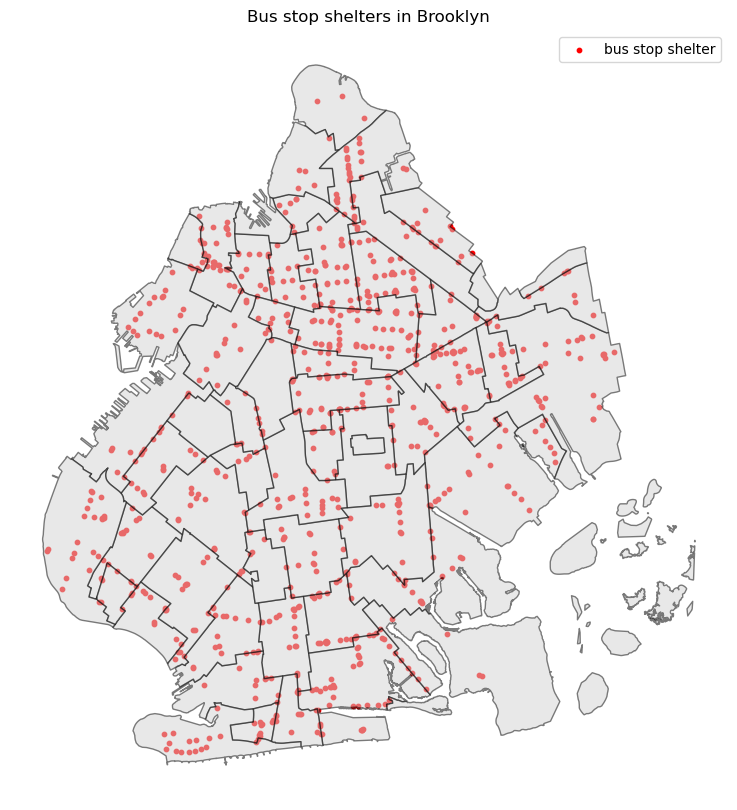

In [45]:
# plot the bus stop shelter on map
fig, ax = plt.subplots(figsize=(10,10))

bus_shelter_bk_gdf.plot(ax=ax, color='red',markersize=10, label="bus stop shelter")
Brooklyn.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

plt.legend()
plt.title("Bus stop shelters in Brooklyn")
ax.axis('off')
plt.show()

In [50]:
print(Brooklyn.crs)  # Left GeoDataFrame
print(bus_shelter_bk_gdf.crs)        # Right GeoDataFrame

EPSG:4326
None


In [51]:
bus_shelter_bk_gdf = bus_shelter_bk_gdf.set_crs("EPSG:4326")

In [53]:
# bus shelter density
# Spatial join to count stations in each neighborhood
brooklyn_with_shelter = gpd.sjoin(
    Brooklyn, bus_shelter_bk_gdf, how='left', predicate='contains'
)

# Count the number of stations in each neighborhood
shelter_density = brooklyn_with_shelter.groupby('NTACode').size().reset_index(name='shelter_count')

Brooklyn_bus_density = Brooklyn.merge(shelter_density, on='NTACode', how='left', suffixes=('_bk', '_shelter'))
Brooklyn_bus_density['shelter_count'] = Brooklyn_bus_density['shelter_count'].fillna(0)

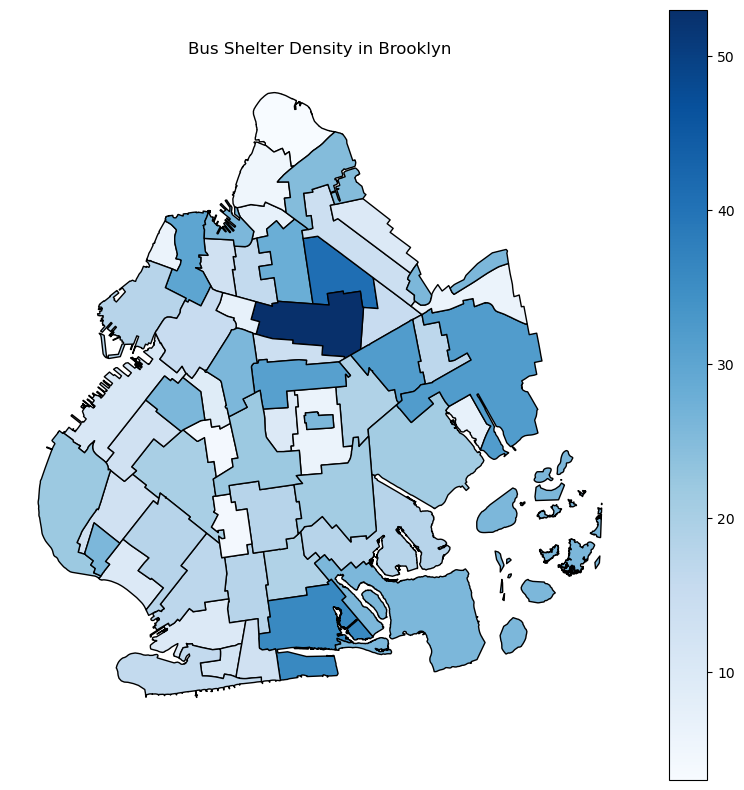

In [55]:
# Plot neighborhoods with station density
fig, ax = plt.subplots(figsize=(10, 10))
Brooklyn_bus_density.plot(
    ax=ax, column='shelter_count', cmap='Blues', edgecolor='black', legend=True
)

ax.axis('off')

plt.title("Bus Shelter Density in Brooklyn")
####plt.savefig("Bus Shelter Density in Northern Brooklyn.png", dpi=300, transparent=True)
plt.show()

In [59]:
print(brooklyn_with_shelter.head())
print(brooklyn_with_shelter.columns)

   OBJECTID  BoroCode_left BoroName_left CountyFIPS NTACode  NTAName_left  \
0         1              3      Brooklyn        047    BK88  Borough Park   
0         1              3      Brooklyn        047    BK88  Borough Park   
0         1              3      Brooklyn        047    BK88  Borough Park   
0         1              3      Brooklyn        047    BK88  Borough Park   
0         1              3      Brooklyn        047    BK88  Borough Park   

    Shape__Area  Shape__Length  \
0  5.400502e+07   39247.228028   
0  5.400502e+07   39247.228028   
0  5.400502e+07   39247.228028   
0  5.400502e+07   39247.228028   
0  5.400502e+07   39247.228028   

                                            geometry  index_right  ...  \
0  POLYGON ((-73.97605 40.63128, -73.97717 40.630...          191  ...   
0  POLYGON ((-73.97605 40.63128, -73.97717 40.630...          195  ...   
0  POLYGON ((-73.97605 40.63128, -73.97717 40.630...          659  ...   
0  POLYGON ((-73.97605 40.63128, -73

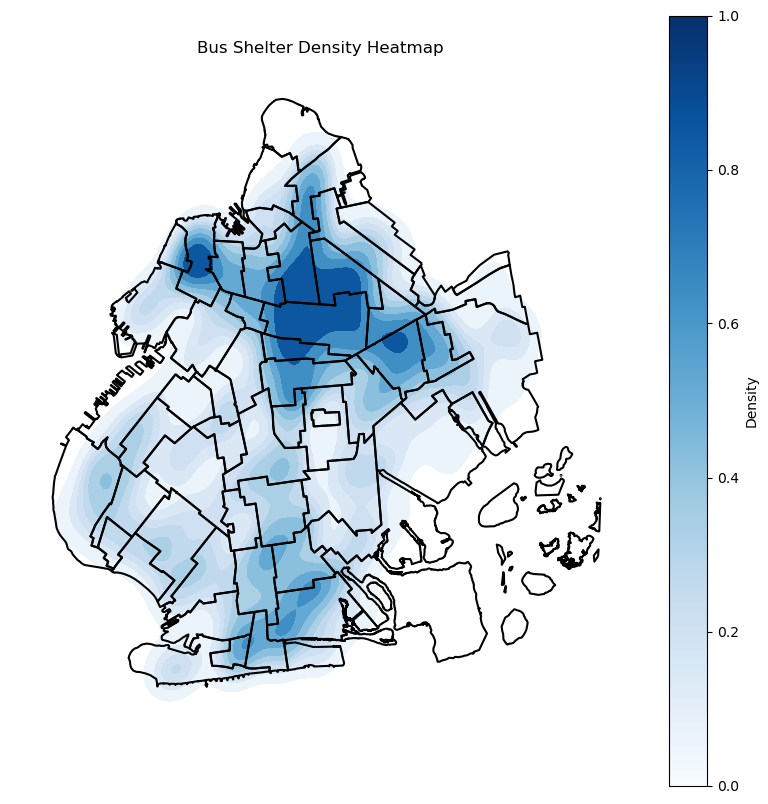

In [66]:
# Plot kernel density map
fig, ax = plt.subplots(figsize=(10, 10))

coords = brooklyn_with_shelter[['Longitude', 'Latitude']]

sns.kdeplot(
    x=coords['Longitude'], y=coords['Latitude'], fill=True, cmap='Blues', bw_adjust=0.5, ax=ax
)
Brooklyn.boundary.plot(ax=ax, edgecolor='black')  # Overlay neighborhood boundaries
plt.title("Bus Shelter Density Heatmap")

#not sure why it does not automatically show up
norm = plt.cm.ScalarMappable(cmap='Blues')
norm.set_array([])
cbar = fig.colorbar(norm, ax=ax)
cbar.set_label('Density')

ax.axis('off')

####plt.savefig("Bus Shelter Density in Northern Brooklyn.png", dpi=300, transparent=True)
plt.show()

# 3. Analysis_Subway in Brooklyn

In [70]:
# load subway data 
subway_lines = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/final_project/data_subway/Subway Lines.geojson')
subway_stations = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/final_project/data_subway/subway-stations.geojson')

In [71]:
subway_lines.head(2)

,name,url,rt_symbol,objectid,id,shape_len,geometry
0,G,http://web.mta.info/nyct/service/,G,753,2000393,2438.20024902,"LINESTRING (-73.99488 40.6802, -73.99427 40.68..."
1,G,http://web.mta.info/nyct/service/,G,754,2000394,3872.83441063,"LINESTRING (-73.97958 40.65993, -73.97966 40.6..."


In [72]:
subway_stations.head(2)

,name,description,geometry
0,geo_arq3-7z49-1.1,"<h4>geo_arq3-7z49-1</h4>\n\n<ul class=""textatt...",POINT (-74.00031 40.73225)
1,geo_arq3-7z49-1.2,"<h4>geo_arq3-7z49-1</h4>\n\n<ul class=""textatt...",POINT (-73.83257 40.84681)


In [73]:
# Filter the data within study area
subway_lines_bk = gpd.clip(subway_lines, Brooklyn)

In [76]:
# check if their Coordinate Reference System are the same
print("Brooklyn CRS:", Brooklyn.crs)
print("Subway Stations CRS:", subway_stations.crs)

Brooklyn CRS: EPSG:4326
Subway Stations CRS: EPSG:4326


In [77]:
# Clip subway stations to Brooklyn
subway_stations_bk = gpd.clip(subway_stations, Brooklyn)

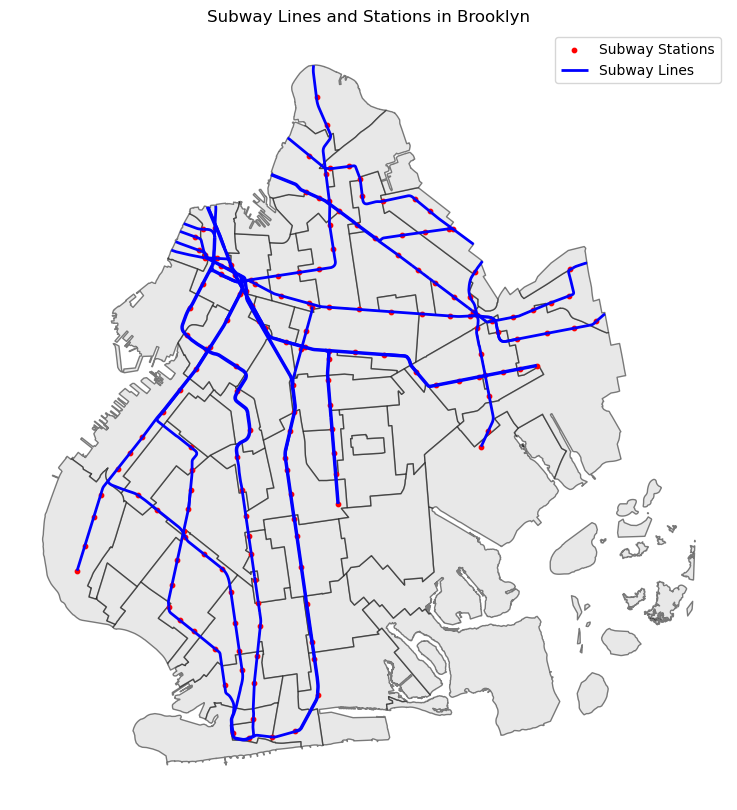

In [80]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Brooklyn boundaries
Brooklyn.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# Plot subway stations
subway_stations_bk.plot(ax=ax, color='red', markersize=10, label="Subway Stations")

# Plot subway lines
subway_lines_bk.plot(ax=ax, color='blue', linewidth=2, label="Subway Lines")


# Add legend and title
plt.legend()
plt.title("Subway Lines and Stations in Brooklyn")
ax.axis('off')
plt.show()

In [83]:
# subway station density
# Spatial join to count stations in each neighborhood
brooklyn_with_stations = gpd.sjoin(
    Brooklyn, subway_stations, how='left', predicate='contains'
)

# Count the number of stations in each neighborhood
station_density = brooklyn_with_stations.groupby('NTAName').size().reset_index(name='station_count')

# Merge station count back into the neighborhood GeoDataFrame
Brooklyn = Brooklyn.merge(station_density, on='NTAName', how='left')
Brooklyn['station_count'] = Brooklyn['station_count'].fillna(0)  

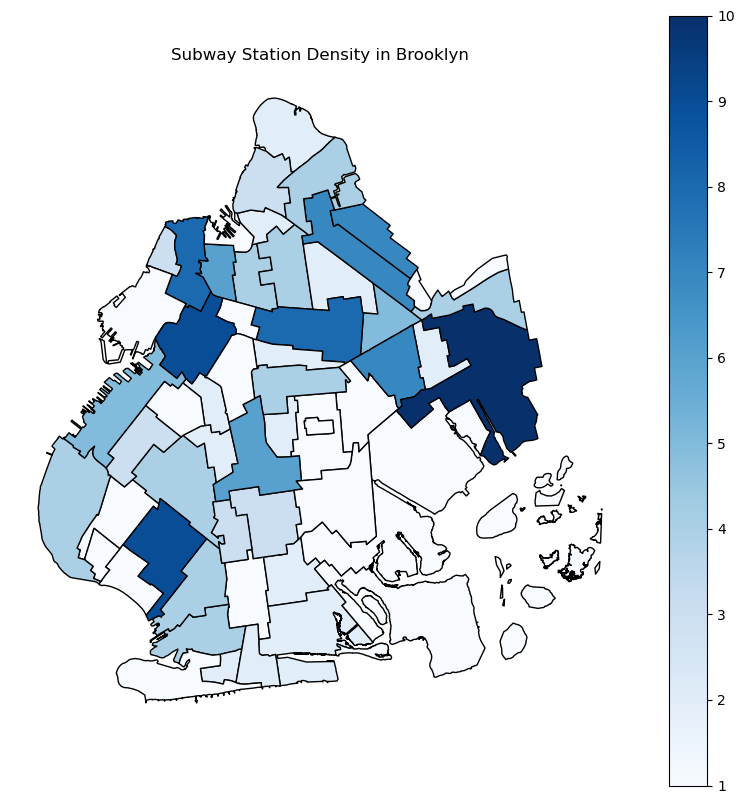

In [91]:
# Plot neighborhoods with station density
fig, ax = plt.subplots(figsize=(10, 10))
Brooklyn.plot(
    ax=ax, column='station_count', cmap='Blues', edgecolor='black', legend=True
)
plt.title("Subway Station Density in Brooklyn")
ax.axis('off')
plt.show()

In [87]:
print(subway_stations_bk.head())
print(subway_stations_bk.columns)

                    name                                        description  \
159  geo_arq3-7z49-1.160  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
27    geo_arq3-7z49-1.28  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
327  geo_arq3-7z49-1.328  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
333  geo_arq3-7z49-1.334  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
334  geo_arq3-7z49-1.335  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   

                       geometry  
159  POINT (-73.97596 40.57603)  
27    POINT (-73.9685 40.57631)  
327  POINT (-73.96135 40.57771)  
333  POINT (-73.97459 40.58074)  
334  POINT (-73.97427 40.58945)  
Index(['name', 'description', 'geometry'], dtype='object')


In [89]:
subway_stations_bk = subway_stations_bk.copy()
# Extract longitude and latitude from the geometry column
subway_stations_bk['lon'] = subway_stations_bk.geometry.x
subway_stations_bk['lat'] = subway_stations_bk.geometry.y

# Check the updated DataFrame
print(subway_stations_bk.head())

                    name                                        description  \
159  geo_arq3-7z49-1.160  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
27    geo_arq3-7z49-1.28  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
327  geo_arq3-7z49-1.328  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
333  geo_arq3-7z49-1.334  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   
334  geo_arq3-7z49-1.335  <h4>geo_arq3-7z49-1</h4>\n\n<ul class="textatt...   

                       geometry        lon        lat  
159  POINT (-73.97596 40.57603) -73.975958  40.576034  
27    POINT (-73.9685 40.57631) -73.968501  40.576312  
327  POINT (-73.96135 40.57771) -73.961354  40.577711  
333  POINT (-73.97459 40.58074) -73.974593  40.580739  
334  POINT (-73.97427 40.58945) -73.974266  40.589450  


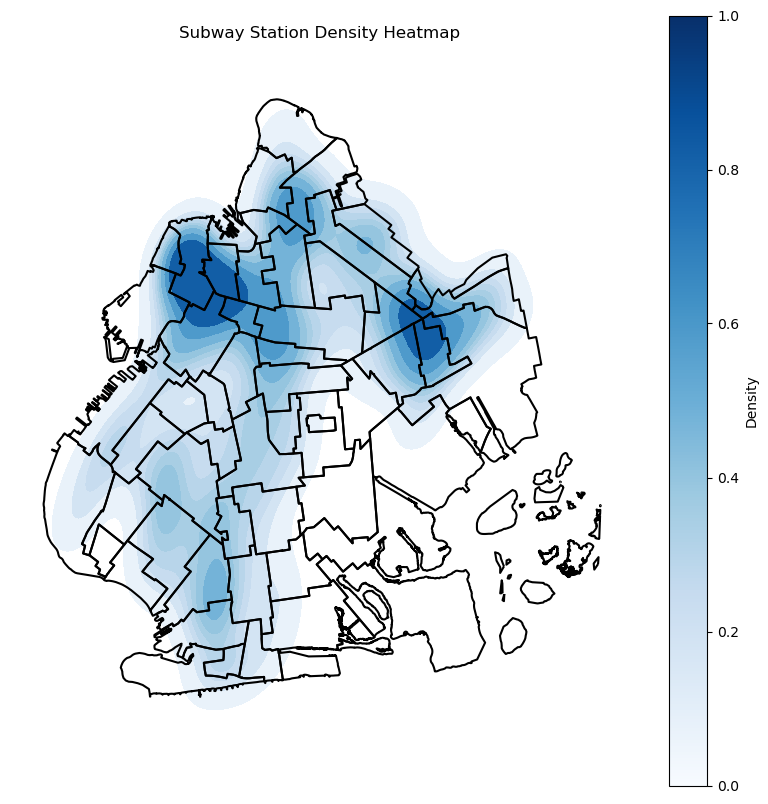

In [92]:
# Plot kernel density map
# Extract coordinates for heatmap
coords = subway_stations_bk[['lon', 'lat']]

# Create heatmap with updated parameter

fig, ax = plt.subplots(figsize=(10, 10))
sns.kdeplot(
    x=coords['lon'], y=coords['lat'], fill=True, cmap='Blues', bw_adjust=0.5
)
Brooklyn.boundary.plot(ax=plt.gca(), edgecolor='black')  # Overlay neighborhood boundaries

#not sure why it does not automatically show up
norm = plt.cm.ScalarMappable(cmap='Blues')
norm.set_array([])
cbar = fig.colorbar(norm, ax=ax)
cbar.set_label('Density')

plt.title("Subway Station Density Heatmap")
ax.axis('off')
plt.show()


# 4. Analysis_Median Income in Brooklyn

In [93]:
# load census data
census_data = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/final_project/data_boro/Kings County_Income.csv')

In [99]:
# Check column names
print(community_bk.columns)
print(census_data.columns)

# Check the first few rows of GEOID
print(community_bk['GEOID'].head())
print(census_data['GEOID'].head())

Index(['CTLabel', 'BoroCode', 'BoroName', 'CT2020', 'BoroCT2020', 'CDEligibil',
       'NTAName', 'NTA2020', 'CDTA2020', 'CDTANAME', 'GEOID', 'PUMA',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')
Index(['GEOID', 'Geographic Area Name', 'Total_Number_Households',
       'Median income_Households', 'Median income (dollars)_White',
       'Median income_Black or African American',
       'Median income_American Indian and Alaska Native',
       'Median income_Asian',
       'Median income_Native Hawaiian and Other Pacific Islander',
       'Median income_Some other race', 'Median income_Two or more races',
       'Median income_Hispanic or Latino origin (of any race)',
       'Median income_White alone, not Hispanic or Latino', 'Total_Workers',
       'Total_Workers_Median age (years)', 'Public transportation_popu',
       'Public transportation_$1 to $9,999 or loss',
       'Public transportation_$10,000 to $14,999',
       'Public transportation_$15,000 to $24,99

In [102]:
# Merge community_map with census_data on GEOID
community_ct_merged = community_bk.merge(
    census_data,
    on='GEOID',  # Common column for merging
    how='inner'  # Keep only matching rows
)

# Display the first few rows of the merged GeoDataFrame
print(community_ct_merged.head())

  CTLabel BoroCode  BoroName  CT2020 BoroCT2020 CDEligibil  \
0     352        3  Brooklyn  035200    3035200       None   
1     350        3  Brooklyn  035000    3035000       None   
2  356.02        3  Brooklyn  035602    3035602       None   
3     354        3  Brooklyn  035400    3035400       None   
4  356.01        3  Brooklyn  035601    3035601       None   

                 NTAName NTA2020 CDTA2020  \
0  Coney Island-Sea Gate  BK1302     BK13   
1  Coney Island-Sea Gate  BK1302     BK13   
2  Coney Island-Sea Gate  BK1302     BK13   
3  Coney Island-Sea Gate  BK1302     BK13   
4  Coney Island-Sea Gate  BK1302     BK13   

                                            CDTANAME  ...  \
0  BK13 Coney Island-Brighton Beach (CD 13 Approx...  ...   
1  BK13 Coney Island-Brighton Beach (CD 13 Approx...  ...   
2  BK13 Coney Island-Brighton Beach (CD 13 Approx...  ...   
3  BK13 Coney Island-Brighton Beach (CD 13 Approx...  ...   
4  BK13 Coney Island-Brighton Beach (CD 13 Approx..

In [103]:
# Check the columns in the merged GeoDataFrame
print(community_ct_merged.columns)

# Check if 'Median_Income' or other desired columns are present
if 'Median_Income' in community_ct_merged.columns:
    print("Income data successfully merged!")
else:
    print("Income data not found in the merged dataset.")

Index(['CTLabel', 'BoroCode', 'BoroName', 'CT2020', 'BoroCT2020', 'CDEligibil',
       'NTAName', 'NTA2020', 'CDTA2020', 'CDTANAME', 'GEOID', 'PUMA',
       'Shape_Leng', 'Shape_Area', 'geometry', 'Geographic Area Name',
       'Total_Number_Households', 'Median income_Households',
       'Median income (dollars)_White',
       'Median income_Black or African American',
       'Median income_American Indian and Alaska Native',
       'Median income_Asian',
       'Median income_Native Hawaiian and Other Pacific Islander',
       'Median income_Some other race', 'Median income_Two or more races',
       'Median income_Hispanic or Latino origin (of any race)',
       'Median income_White alone, not Hispanic or Latino', 'Total_Workers',
       'Total_Workers_Median age (years)', 'Public transportation_popu',
       'Public transportation_$1 to $9,999 or loss',
       'Public transportation_$10,000 to $14,999',
       'Public transportation_$15,000 to $24,999',
       'Public transportatio

In [104]:
# Find unmatched GEOID values
unmatched_geoids = set(census_data['GEOID']) - set(community_bk['GEOID'])
print("Unmatched GEOIDs:", unmatched_geoids)

Unmatched GEOIDs: {'36047990100'}


In [105]:
community_ct_merged = community_bk.merge(
    census_data,
    on='GEOID',
    how='left'  # Keep all rows from community_map
)

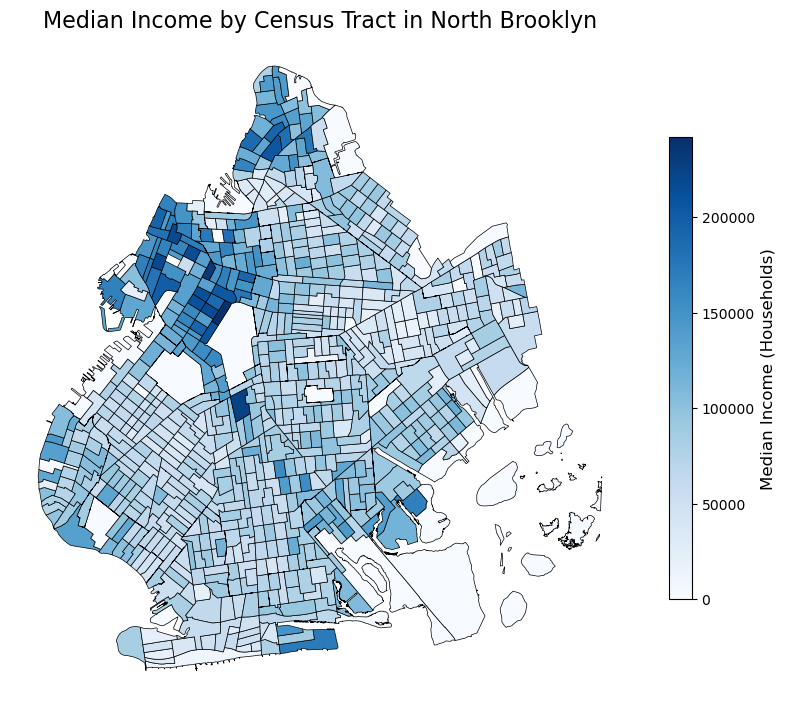

In [122]:
# Ensure the column is numeric
community_ct_merged['Median income_Households'] = pd.to_numeric(
    community_ct_merged['Median income_Households'], errors='coerce'
)

# Handle missing values if any were converted to NaN
community_ct_merged = community_ct_merged.dropna(subset=['Median income_Households'])

# Define the column to use for the plot and the color map
column = 'Median income_Households'
cmap = 'Blues'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))
community_ct_merged.plot(
    column=column,
    cmap=cmap,
    edgecolor='black',
    linewidth=0.5,
    legend=False,  # Disable the default legend
    ax=ax
)

# Create a manual color bar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=mpl.colors.Normalize(
        vmin=community_ct_merged[column].min(),
        vmax=community_ct_merged[column].max()
    )
)
sm._A = []  # Add dummy data to make the ScalarMappable work
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=20)  # Adjust size and aspect ratio
cbar.set_label("Median Income (Households)", fontsize=12)

# Customize the plot
ax.axis('off')
plt.title("Median Income by Census Tract in North Brooklyn", fontsize=16)
plt.show()

## 4.2 Aggregate Census Tract Data to Neighborhood level

In [128]:
Brooklyn_ct = Brooklyn.to_crs(community_ct_merged.crs)

In [136]:
community_with_neighborhoods = gpd.sjoin(community_ct_merged, Brooklyn, how="inner", predicate="intersects")

In [137]:
print(Brooklyn_ct.columns)  # Check the neighborhood-level GeoDataFrame columns
print(community_with_neighborhoods.columns)  # Check the aggregated data columns

Index(['OBJECTID', 'BoroCode', 'BoroName', 'CountyFIPS', 'NTACode', 'NTAName',
       'Shape__Area', 'Shape__Length', 'geometry', 'station_count'],
      dtype='object')
Index(['CTLabel', 'BoroCode_left', 'BoroName_left', 'CT2020', 'BoroCT2020',
       'CDEligibil', 'NTAName_left', 'NTA2020', 'CDTA2020', 'CDTANAME',
       'GEOID', 'PUMA', 'Shape_Leng', 'Shape_Area', 'geometry',
       'Geographic Area Name', 'Total_Number_Households',
       'Median income_Households', 'Median income (dollars)_White',
       'Median income_Black or African American',
       'Median income_American Indian and Alaska Native',
       'Median income_Asian',
       'Median income_Native Hawaiian and Other Pacific Islander',
       'Median income_Some other race', 'Median income_Two or more races',
       'Median income_Hispanic or Latino origin (of any race)',
       'Median income_White alone, not Hispanic or Latino', 'Total_Workers',
       'Total_Workers_Median age (years)', 'Public transportation_popu'

In [138]:
# Group by neighborhood names (assuming the column is 'neighborhood_name')
neighborhood_data = community_with_neighborhoods.groupby('NTACode').agg({
    'Median income_Households': 'mean',  # Use mean, sum, or another appropriate aggregation method
    # Add other columns if needed for aggregation
}).reset_index()

# Merge the aggregated data back into the Brooklyn GeoDataFrame
Brooklyn_ct = Brooklyn.merge(neighborhood_data, left_on='NTACode', right_on='NTACode', how='left')

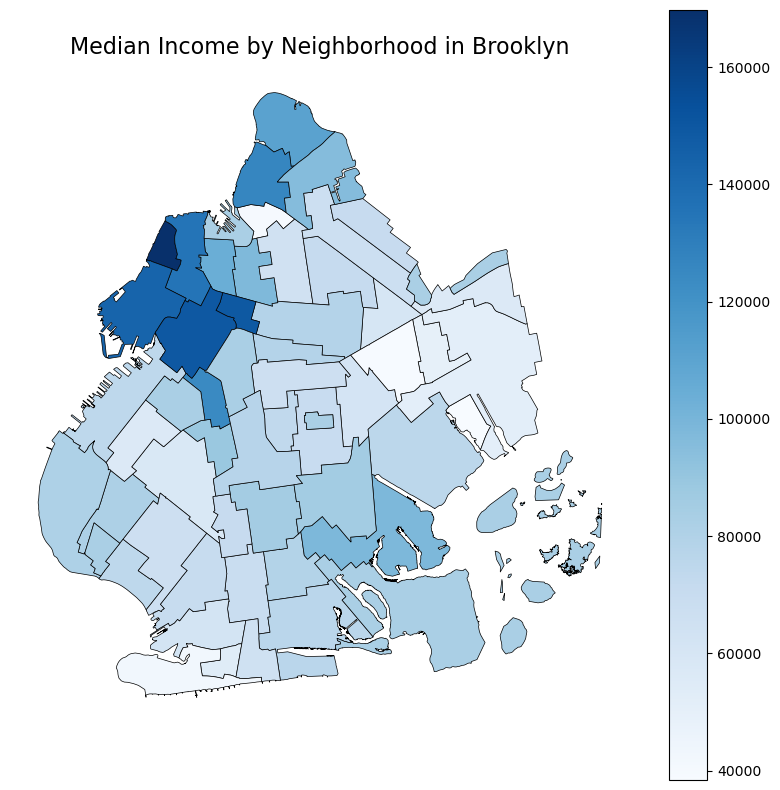

In [144]:
fig, ax = plt.subplots(figsize=(10, 10))
Brooklyn_ct.plot(
    column='Median income_Households',
    cmap='Blues',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    ax=ax
)

ax.axis('off')
plt.title("Median Income by Neighborhood in Brooklyn", fontsize=16)
plt.show()

# 5. Accessibility Formula